In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
players = pd.read_csv('../data/player_list.csv')
print("Data loaded!")

Data loaded!


차트 저장 완료!


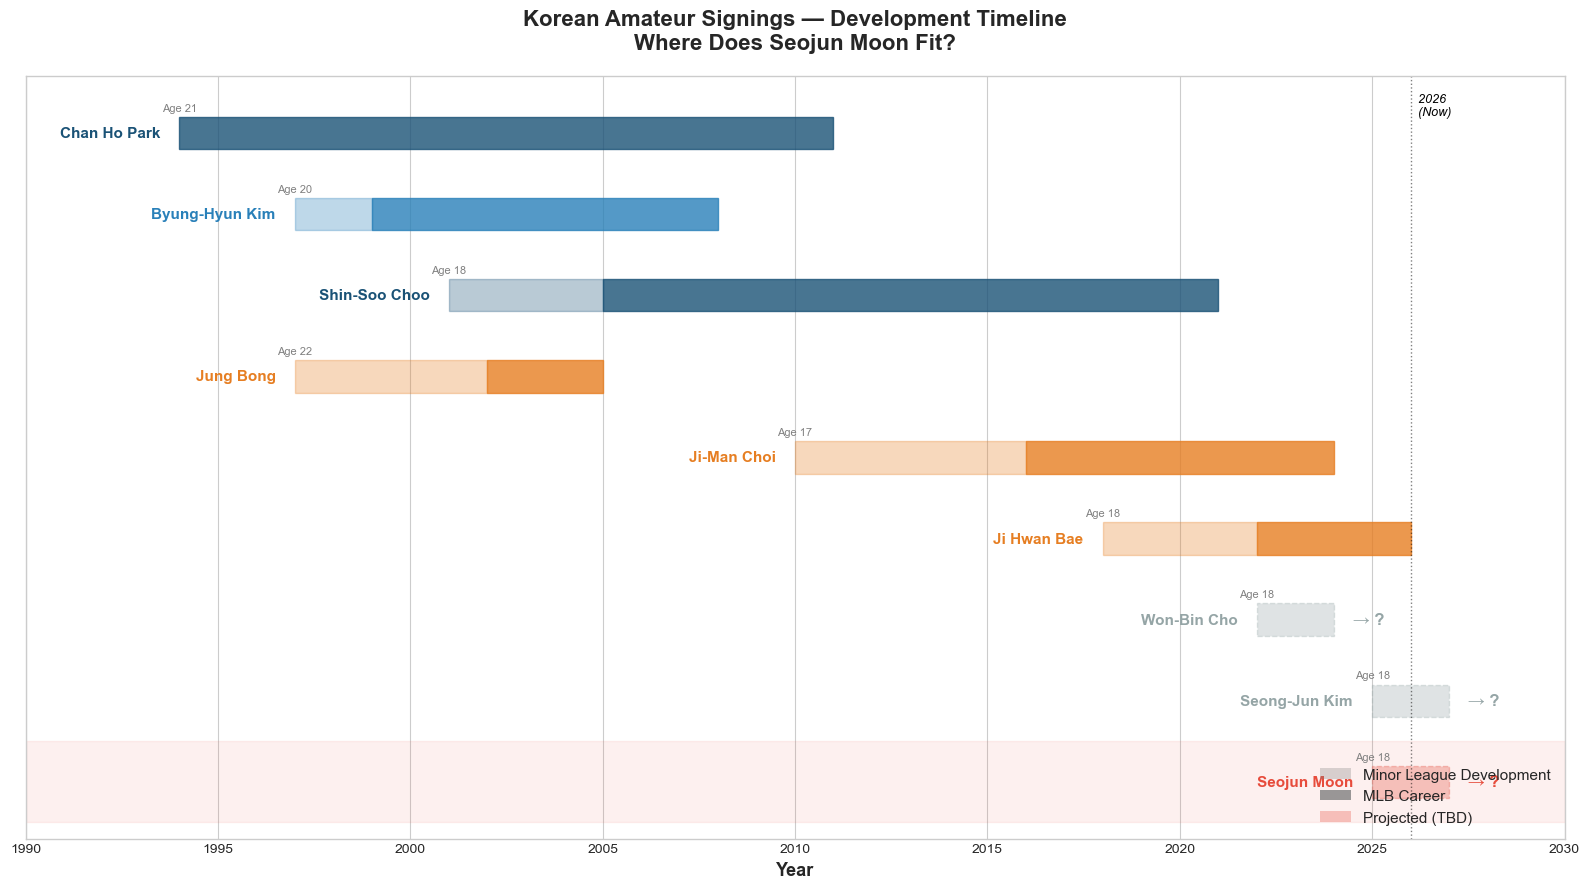

In [2]:
fig, ax = plt.subplots(figsize=(16, 9))

# 선수 데이터 (signing → minor league → MLB debut → MLB end)
timeline_data = [
    # name, signing_year, signing_age, mlb_debut_year, mlb_end_year, tier, tier_color
    ('Chan Ho Park', 1994, 21, 1994, 2010, '1A', '#1a5276'),
    ('Byung-Hyun Kim', 1997, 20, 1999, 2007, '1B', '#2980b9'),
    ('Shin-Soo Choo', 2001, 18, 2005, 2020, '1A', '#1a5276'),
    ('Jung Bong', 1997, 22, 2002, 2004, '2', '#e67e22'),
    ('Ji-Man Choi', 2010, 17, 2016, 2023, '2', '#e67e22'),
    ('Ji Hwan Bae', 2018, 18, 2022, 2025, '2', '#e67e22'),
    ('Won-Bin Cho', 2022, 18, None, None, '3', '#95a5a6'),
    ('Seong-Jun Kim', 2025, 18, None, None, '3', '#95a5a6'),
    ('Seojun Moon', 2025, 18, None, None, '4', '#e74c3c'),
]

for i, (name, sign_yr, sign_age, debut_yr, end_yr, tier, color) in enumerate(timeline_data):
    y = len(timeline_data) - 1 - i  # 위에서부터 아래로
    
    if debut_yr and end_yr:
        # 마이너리그 기간 (signing → debut)
        minor_years = debut_yr - sign_yr
        if minor_years > 0:
            ax.barh(y, minor_years, left=sign_yr, height=0.4,
                    color=color, alpha=0.3, edgecolor=color, linewidth=1)
        
        # MLB 기간 (debut → end)
        mlb_years = end_yr - debut_yr + 1
        ax.barh(y, mlb_years, left=debut_yr, height=0.4,
                color=color, alpha=0.8, edgecolor=color, linewidth=1)
    else:
        # Prospects — 물음표로 미래 표시
        ax.barh(y, 2, left=sign_yr, height=0.4,
                color=color, alpha=0.3, edgecolor=color, linewidth=1,
                linestyle='--')
        ax.text(sign_yr + 2.5, y, '→ ?', fontsize=12, va='center',
                color=color, fontweight='bold')
    
    # 선수 이름
    ax.text(sign_yr - 0.5, y, name, fontsize=11, va='center', ha='right',
            fontweight='bold', color=color)
    
    # Signing age
    ax.text(sign_yr, y + 0.25, f'Age {sign_age}', fontsize=8, va='bottom',
            ha='center', color='gray')

# 문서준 강조 박스
ax.axhspan(-0.5, 0.5, alpha=0.08, color='#e74c3c')

# 범례
legend_elements = [
    mpatches.Patch(facecolor='gray', alpha=0.3, label='Minor League Development'),
    mpatches.Patch(facecolor='gray', alpha=0.8, label='MLB Career'),
    mpatches.Patch(facecolor='#e74c3c', alpha=0.3, linestyle='--', label='Projected (TBD)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

# 축 설정
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_title("Korean Amateur Signings — Development Timeline\nWhere Does Seojun Moon Fit?", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(1990, 2030)
ax.set_ylim(-0.7, len(timeline_data) - 0.3)
ax.set_yticks([])

# 현재 시점 표시
ax.axvline(x=2026, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.text(2026, len(timeline_data) - 0.5, '  2026\n  (Now)', fontsize=9,
        va='top', color='black', fontstyle='italic')

plt.tight_layout()
plt.savefig('../visualizations/09_moon_development_timeline.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

차트 저장 완료!


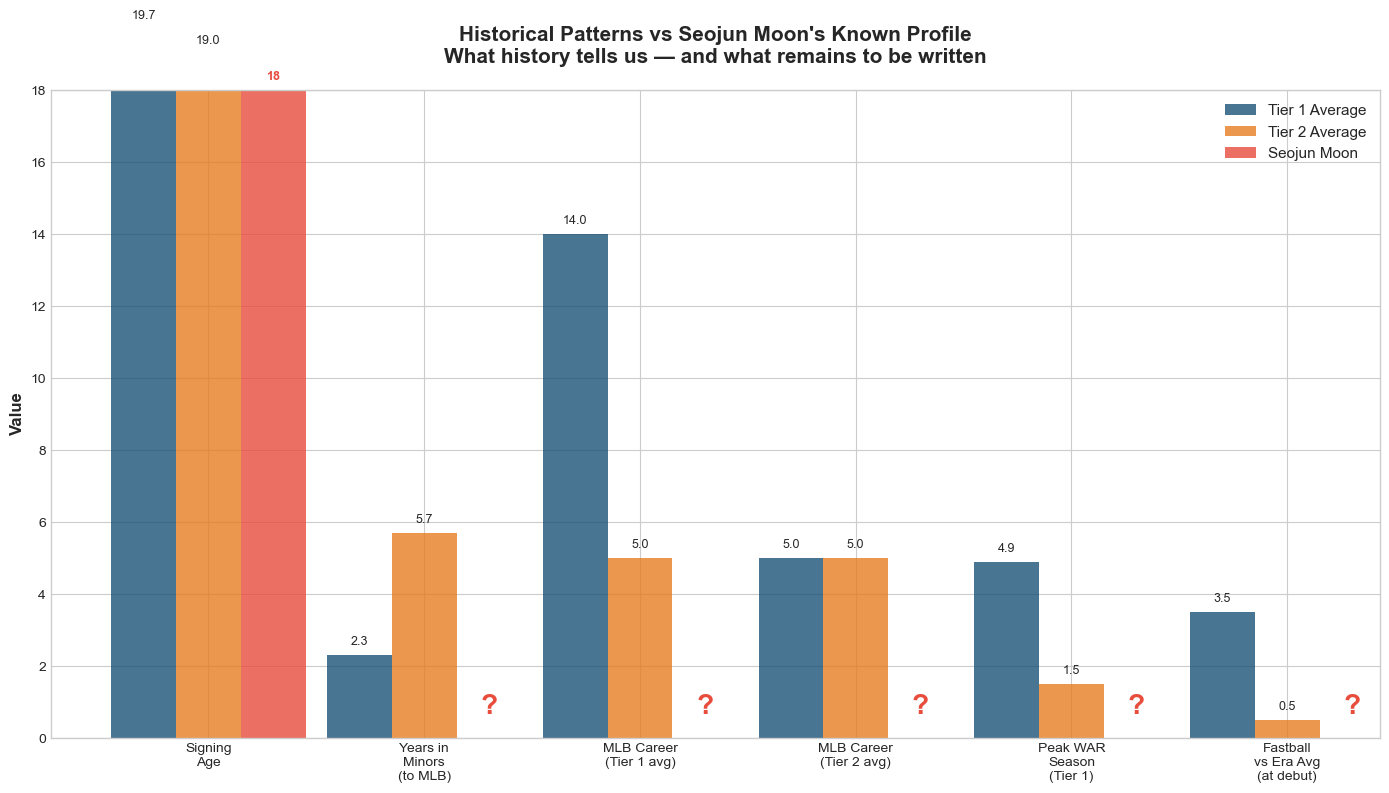

In [3]:
fig, ax = plt.subplots(figsize=(14, 8))

# 한국 amateur signing의 historical pattern 요약
categories = [
    'Signing\nAge',
    'Years in\nMinors\n(to MLB)',
    'MLB Career\n(Tier 1 avg)',
    'MLB Career\n(Tier 2 avg)',
    'Peak WAR\nSeason\n(Tier 1)',
    'Fastball\nvs Era Avg\n(at debut)'
]

# Historical averages
tier1_values = [19.7, 2.3, 14.0, 5.0, 4.9, 3.5]   # Tier 1 평균
tier2_values = [19.0, 5.7, 5.0, 5.0, 1.5, 0.5]     # Tier 2 평균
moon_values =  [18, None, None, None, None, 0]       # 문서준 (known + unknown)

x = np.arange(len(categories))
width = 0.3

# Tier 1, 2 막대
bars1 = ax.bar(x - width, tier1_values, width, label='Tier 1 Average',
               color='#1a5276', alpha=0.8)
bars2 = ax.bar(x, tier2_values, width, label='Tier 2 Average',
               color='#e67e22', alpha=0.8)

# 문서준 — 알려진 것만 표시
moon_known = [18, 0, 0, 0, 0, 0]  # signing age만 알려짐
moon_bar = ax.bar(x[0] + width, moon_known[0], width, 
                  color='#e74c3c', alpha=0.8, label='Seojun Moon')

# 문서준 미래 영역 — 물음표
for i in range(1, len(categories)):
    ax.text(x[i] + width, 0.5, '?', fontsize=20, ha='center', va='bottom',
            color='#e74c3c', fontweight='bold')

# 값 표시
for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax.text(x[0] + width, 18 + 0.2, '18', ha='center', va='bottom', 
        fontsize=9, color='#e74c3c', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title("Historical Patterns vs Seojun Moon's Known Profile\n"
             "What history tells us — and what remains to be written", 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 18)

plt.tight_layout()
plt.savefig('../visualizations/10_moon_vs_historical.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

## Synthesis: Implications for Seojun Moon's Development

### What We Know
- **Age at signing:** 18 (consistent with Tier 1 average of 19.7)
- **Pitch profile:** 90-95 mph fastball, slider, curveball, changeup (4-pitch mix)
- **Physical frame:** 6'4", 214 lbs (projectable, room for velocity gains)
- **Historical significance:** First Korean-born international signing in Blue Jays history

### What History Tells Us

**From Tier 1 (Success Cases):**
1. **The Pioneer Effect** — Park and Moon share the distinction of being 
   franchise "firsts." This creates organizational commitment to development 
   that can accelerate opportunity.
2. **Patience Pays Off** — Choo took 4 years in the minors. The average 
   Tier 1 path is ~2-3 years to MLB, but rushing can be counterproductive.
3. **Differentiation is Key** — Each Tier 1 player had a unique, elite trait 
   (Park: velocity in a slow era; Kim: submarine delivery; Choo: plate discipline). 
   Moon must identify and develop his differentiator.

**From Tier 2 (Cautionary Tales):**
1. **The Four-A Trap** — Bae's dominance in AAA that evaporated in MLB 
   shows that minor league success does not guarantee MLB translation.
2. **Find a Niche** — Choi survived 8 MLB seasons by excelling in a 
   specific role (platoon 1B vs RHP). Role clarity extends careers.
3. **The Clock is Ticking** — Bong's 3-season MLB career shows that 
   the window for Korean amateur signings can close quickly.

### Era-Adjusted Considerations for Moon (2026+ MLB Environment)
1. **Velocity is baseline, not advantage** — Moon's 90-95 mph in a 
   94.5 mph average era means he cannot rely on velocity alone.
2. **Pitch design is essential** — Modern development focuses on 
   optimizing spin rate, movement profiles, and pitch tunneling. 
   Moon's 4-pitch mix provides raw material for this optimization.
3. **Strikeout ability is expected** — In a K/9 ~8.4 era, the ability 
   to generate swings and misses is table stakes, not a differentiator.
4. **Secondary pitches determine ceiling** — Moon's slider development 
   will likely be the single most important factor in his MLB trajectory.

### Recommendation Framework
Based on 30 years of Korean amateur signing data, the following 
development priorities emerge for Seojun Moon:

1. **Years 1-2 (Minor Leagues):** Focus on pitch design optimization. 
   Identify which secondary pitch has the highest swing-and-miss potential.
2. **Years 2-3:** Gradual advancement through minor league levels. 
   Historical average for successful Korean pitchers is ~2-3 years.
3. **Years 3-5:** MLB readiness assessment. The key metric is not 
   velocity but pitch quality — can his secondary pitches generate 
   MLB-level whiffs?
4. **Bilingual advantage:** The Blue Jays' investment in Korean scouting 
   (Moon as the first signing) suggests a long-term pipeline strategy. 
   Having Korean-speaking support staff during development is a 
   competitive advantage that previous Korean signings did not have.